# ISYS2407 Information Systems Solutions & Design  
# Assignment 3: Model 1 - K-Nearest Neighbours (All Features)  

#### Student Name: Lam Le
#### Student Number: s4032582
#### Dataset: cleaned_personal_loan.pkl  

---

### Purpose  
This notebook initiates the **Modelling Phase** for the *Crédit Nationale Azur Personal Loan Campaign Project*.  
Using the cleaned dataset produced in *02-data-cleaning.ipynb*, the goal is to build a **baseline K-Nearest Neighbours (KNN)** classifier to predict whether a customer will accept a Personal Loan (`personal_loan = 1`).  

The model utilises all available numeric and categorical predictors from the cleaned dataset, without any feature elimination or hyperparameter optimisation.  
Because KNN relies on distance metrics, correct **feature scaling** is essential to ensure fair weighting across income, mortgage, and account-related variables.  
Results from this baseline KNN will act as the benchmark for future notebooks that apply **class rebalancing**, **hyperparameter tuning**, and **feature selection**.  

---

### Method  
1. **Load Dataset**  
   - Import `cleaned_personal_loan.pkl` created in the Data Cleaning notebook to maintain consistent variable types and encodings.  

2. **Train–Test Split**  
   - Divide the dataset into **80 % training** and **20 % testing** sets using `stratify=y` to preserve the loan-acceptance class distribution.  

3. **Data Transformation**  
   - Apply `StandardScaler` to all continuous variables so that KNN’s Euclidean distance treats each feature equally.  
   - *(Optional)* Demonstrate light discretisation of **income** into categories (low, medium, high) and one-hot encode them for comparison.  

4. **Model Construction**  
   - Instantiate `KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2)` to establish a simple, interpretable baseline.  
   - Embed the scaler and model inside a `Pipeline` to prevent data leakage and streamline deployment.  

5. **Model Evaluation**  
   - Assess performance using key Week 10–11 metrics:  
     - Accuracy, Precision, Recall, F1, ROC-AUC, and **PR-AUC** (imbalance-aware).  
   - Generate diagnostic visuals:  
     - **Confusion Matrix** (error types)  
     - **ROC Curve** (rank performance)  
     - **Precision–Recall Curve** 

6. **Model Saving**  
   - Export the trained pipeline as `model1_knn_all_features.joblib` and store metrics in `model1_knn_all_features_metrics.json` for reproducibility.  

---

### Interpretation  
The baseline KNN typically provides a strong **non-parametric benchmark** yet is sensitive to unscaled or noisy data.  
Initial results are expected to show good overall **accuracy** but limited **recall** for the minority (loan-accepted) class, producing several **false negatives**—customers who likely would have accepted a loan but were misclassified.  
While this conservative prediction style avoids false positives (marketing overspend), it can reduce campaign reach.  
From a business viewpoint, false negatives represent **missed revenue opportunities**, whereas false positives increase **marketing costs**.  
These trade-offs emphasise the need for future **threshold adjustment** and **class-balancing techniques** in subsequent modelling stages.  

---

### Outcome  
- A fully implemented **baseline KNN pipeline** trained on all cleaned features.  
- Core performance metrics (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC) and key diagnostic visuals.  
- Foundational benchmark for comparing tuned and imbalance-adjusted models in later phases.  


# 1 Binary Classification  

### Purpose  
This section begins the **model-building process** by preparing the cleaned dataset for classification.  
The aim is to establish a reliable foundation for the **K-Nearest Neighbours (KNN)** model by ensuring that data loading, feature–target separation, and train–test splitting are performed correctly and reproducibly.  
As KNN is a **supervised binary classifier**, this step confirms that the target variable (`personal_loan`) and predictor variables are correctly defined before modelling.

### Method  
1. **Import essential libraries**  
   - Data handling: `pandas`, `numpy`.  
   - Model preparation: `train_test_split` from `sklearn.model_selection`.  
   - Scaling and preprocessing: `StandardScaler` from `sklearn.preprocessing`.  
   - Metrics and evaluation: `sklearn.metrics`.  
   - Model: `KNeighborsClassifier` from `sklearn.neighbors`.  
   - Visualisation: `matplotlib`, `seaborn`.  
   - Persistence: `joblib` for saving models.  

2. **Load the cleaned dataset**  
   - Load the file `cleaned_personal_loan.pkl` produced in *02-data-cleaning.ipynb* to ensure data consistency.  
   - Verify structure and completeness using:  
     - `df.shape`, `df.head()` to confirm record and feature counts.  
     - `df.info()` to review variable types.  
     - `df['personal_loan'].value_counts(normalize=True)` to check class distribution.  

3. **Define features and target variable**  
   - Select all explanatory variables except identifiers (`customer_id`) and target (`personal_loan`).  
   - Store predictors in **X** and the target label in **y**.

4. **Split into training and testing sets**  
   - Use `train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)` to create an **80–20 stratified split**, maintaining class balance between loan-accepted and non-accepted customers.  
   - Print shapes of resulting sets to confirm correct separation.  

### Outcome  
- All required libraries imported and dataset successfully loaded from the cleaning phase.  
- Target (`personal_loan`) and predictors defined correctly.  
- Class balance verified to detect potential data imbalance.  
- Training and testing sets prepared with consistent, stratified sampling for fair model evaluation in later stages.


### 1.1 Import Libraries  

Load the essential Python libraries for **data analysis, modelling, and visualisation**.  
These libraries enable efficient data handling, metric evaluation, and plotting for the **K-Nearest Neighbours (KNN)** model.

**Expected Outcome:**  
All core scientific, modelling, and evaluation libraries are imported successfully and ready for use.


In [2]:
# Data handling and numerical computation 
import pandas as pd
import numpy as np

# Data visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model 
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Persistence 
import joblib

# Global settings 
# Set consistent white background and colour palette
plt.style.use('default')  # clean white background
sns.set_style("whitegrid")  # light grid on white
pd.set_option('display.float_format', lambda x: f'{x:.3f}')  # tidy numeric format

# Optional: custom colour for brand consistency
CUSTOM_COLOR = "#136f63"

### 1.2 Import Model Library  

Import the model-specific library required to build the **K-Nearest Neighbours (KNN)** classifier.  
This algorithm forms the foundation of our baseline model by classifying customers based on their proximity to similar observations in the feature space.

**Expected Outcome:**  
The `KNeighborsClassifier` class is successfully imported and ready to initialise the baseline KNN model.


In [3]:
# Import the K-Nearest Neighbours model
from sklearn.neighbors import KNeighborsClassifier

### 1.3 Load the Cleaned Data  

Load the preprocessed dataset generated from *02-data-cleaning.ipynb* to maintain consistent data formatting and encoding across the modelling workflow.  
Initial inspection confirms dataset structure, column integrity, and the balance of the target variable (`personal_loan`).

**Expected Outcome:**  
The cleaned dataset is successfully loaded, inspected for structure, and class distribution is verified.  

In [4]:
# Load the cleaned dataset
personal_loan_df = joblib.load('cleaned_personal_loan.pkl')

# Preview the first few rows
personal_loan_df.head()

,customer_id,age,yrs_experience,family_size,education_level,income,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct,personal_loan,income_log,mortgage_amt_log,credit_card_spend_log
0,3815,40.000,9.000,3.000,2,60.000,0,1,1.700,0,0,1,0,4.111,0.000,0.993
1,5737,65.000,27.000,4.000,3,36.000,90,0,0.000,0,0,1,0,3.611,4.511,0.000
2,4209,61.000,3.000,2.000,1,145.000,314,0,0.000,0,1,1,1,4.984,5.753,0.000
3,4734,29.000,14.000,1.000,1,52.000,0,0,0.000,1,0,1,0,3.970,0.000,0.000
4,2551,43.000,23.000,4.000,2,33.000,0,0,0.000,0,0,1,0,3.526,0.000,0.000


In [5]:
# Check the dataset structure
print("Dataset Shape:", personal_loan_df.shape)
print("\nData Types and Nulls:")
print(personal_loan_df.info())

Dataset Shape: (6000, 16)

Data Types and Nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   customer_id            6000 non-null   Int64   
 1   age                    6000 non-null   float64 
 2   yrs_experience         6000 non-null   float64 
 3   family_size            6000 non-null   float64 
 4   education_level        6000 non-null   category
 5   income                 6000 non-null   float64 
 6   mortgage_amt           6000 non-null   int64   
 7   credit_card_acct       6000 non-null   category
 8   credit_card_spend      6000 non-null   float64 
 9   share_trading_acct     6000 non-null   Int64   
 10  fixed_deposit_acct     6000 non-null   Int64   
 11  online_acct            6000 non-null   category
 12  personal_loan          6000 non-null   category
 13  income_log             6000 non-null   float


Target class distribution (proportion):
personal_loan
0   0.850
1   0.150
Name: proportion, dtype: float64


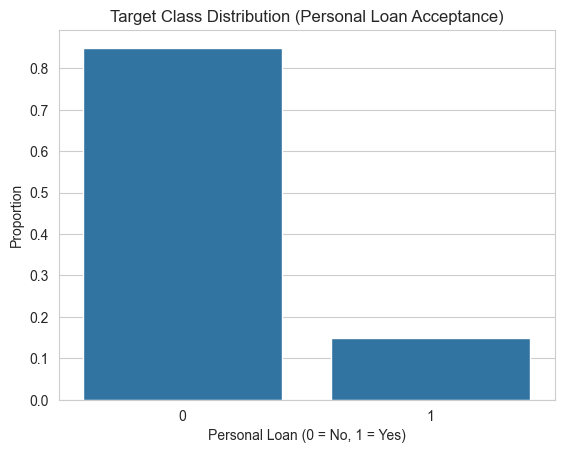

In [6]:
# Check class distribution of the target variable
class_counts = personal_loan_df['personal_loan'].value_counts(normalize=True)
print("\nTarget class distribution (proportion):")
print(class_counts)

# Visualise target class balance
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
)
plt.title("Target Class Distribution (Personal Loan Acceptance)")
plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Proportion")
plt.show()

### 1.4 Define Features & Target & Train/Test Split  

Select relevant features for modelling and separate them from the target variable (`personal_loan`).  
This step prepares the dataset for supervised learning by defining **X** (predictor variables) and **y** (target label).  
The dataset is then divided into **training** and **testing** sets to enable objective model evaluation on unseen data.

**Expected Outcome:**  
Features and target variables are clearly defined, and stratified data splitting ensures fair representation of both loan-accepted and non-accepted customers.


In [7]:
# Define feature columns (exclude identifiers and target)
feature_cols = [
    'age',
    'yrs_experience',
    'family_size',
    'education_level',
    'income',
    'mortgage_amt',
    'credit_card_acct',
    'credit_card_spend',
    'share_trading_acct',
    'fixed_deposit_acct',
    'online_acct'
]

# Define predictors (X) and target (y)
X = personal_loan_df[feature_cols]
y = personal_loan_df['personal_loan']

# Display shapes
print("Feature Matrix Shape (X):", X.shape)
print("Target Vector Shape (y):", y.shape)


Feature Matrix Shape (X): (6000, 11)
Target Vector Shape (y): (6000,)


In [8]:
# Perform stratified train-test split (80–20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Confirm split sizes
print("Training Set Shape:", X_train.shape, y_train.shape)
print("Testing Set Shape:", X_test.shape, y_test.shape)


Training Set Shape: (4800, 11) (4800,)
Testing Set Shape: (1200, 11) (1200,)


# 2 Data Transformation  

### Purpose  
This section applies **scaling and encoding transformations** to prepare the dataset for the K-Nearest Neighbours (KNN) algorithm.  
Because KNN measures distance between observations, all continuous variables must be scaled to ensure equal influence across features.  
In addition, light categorical encoding (e.g., for discretised income categories) is performed to maintain numerical compatibility with the model.

### Method  
1. **Feature Scaling**  
   - Apply `StandardScaler` to all continuous variables to standardise them around mean = 0 and standard deviation = 1.  
   - Scaling is fitted **only on the training data** and then applied to both train and test sets to avoid data leakage.  
   - This ensures that distance computations in KNN are not biased by differing numeric ranges (e.g., `income` vs `age`).  

2. **(Optional) Discretisation of Income**  
   - Transform `income` into categorical labels such as `"low_income"`, `"medium_income"`, and `"high_income"` based on defined thresholds.  
   - This step provides an interpretable feature reflecting customer income tiers.

3. **(Optional) One-Hot Encoding**  
   - Convert the new `income_category` variable into binary columns using `pd.get_dummies()` to retain numerical format.  
   - Apply the same encoding structure to both training and testing sets.

4. **Verification**  
   - Display the first few rows of transformed data with `.head()` and confirm shape consistency between training and testing sets.  
   - Check that all columns are numeric and ready for model fitting.

### Outcome  
- All continuous variables standardised for fair distance measurement in KNN.  
- Optional categorical transformations (discretisation and encoding) applied consistently.  
- Final training and testing datasets verified for shape, scaling integrity, and numeric readiness before model building.


### 2.1 Scaling (post-split, train-only fit)  

Standardise feature scales to ensure **distance calculations** in KNN are meaningful.  
Scaling is **fitted on `X_train` only** and then **applied to both** training and testing sets to prevent data leakage.

**Expected Outcome:**  
Continuous (and binary flag) features are scaled; transformed matrices are ready for modelling.  
A **pipeline** is also prepared to use scaling + KNN together for safer, deployable training.


In [9]:
# Choose columns to scale.
# For distance-based KNN, it's acceptable to scale *all* numeric features (incl. binary flags).
columns_to_scale = X_train.columns.tolist()

scaler = StandardScaler()

# Fit ONLY on the training data
scaler.fit(X_train[columns_to_scale])

# Transform both train and test
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train[columns_to_scale]),
    columns=columns_to_scale,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[columns_to_scale]),
    columns=columns_to_scale,
    index=X_test.index
)

# Quick verification
print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)
X_train_scaled.head()


Scaled shapes: (4800, 11) (1200, 11)


,age,yrs_experience,family_size,education_level,income,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct
1207,0.980,-1.418,1.231,0.138,0.473,-0.780,-0.648,-0.445,-0.327,-0.282,0.816
1429,0.231,-1.494,1.231,1.331,-0.308,1.778,1.542,1.361,-0.327,-0.282,0.816
1347,-0.218,-1.570,1.231,0.138,1.338,-0.780,-0.648,-0.445,-0.327,-0.282,-1.225
1801,-0.293,1.018,-1.264,-1.055,-0.033,0.103,1.542,1.867,-0.327,-0.282,0.816
4870,0.830,1.475,1.231,1.331,0.135,0.440,-0.648,-0.445,-0.327,-0.282,-1.225


### 2.2 Discretisation of a Continuous Feature  

Discretise a continuous feature into **categorical bins** to improve interpretability and capture potential non-linear patterns.  
For demonstration, the `income` variable is grouped into **low**, **medium**, and **high** categories using simple, assignment-appropriate thresholds.  
This step is optional and intended for exploratory comparison.

**Expected Outcome:**  
A new feature `income_category` is created in both training and testing sets, and the original `income` column is removed.


In [10]:
# Make copies to avoid slice warnings
X_train_disc = X_train_scaled.copy()
X_test_disc = X_test_scaled.copy()

# Define a simple function to group income values into categories
def income_category(row):
    if row["income"] <= 26:
        return "low_income"
    elif 26 < row["income"] <= 103.9:
        return "medium_income"
    else:
        return "high_income"

# Apply to both training and testing data
X_train_disc["income_category"] = X_train_disc.apply(lambda x: income_category(x), axis=1)
X_test_disc["income_category"] = X_test_disc.apply(lambda x: income_category(x), axis=1)

# Remove the original continuous column
X_train_disc.drop(["income"], axis=1, inplace=True)
X_test_disc.drop(["income"], axis=1, inplace=True)

# Check the transformed data
X_train_disc.head()


,age,yrs_experience,family_size,education_level,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct,income_category
1207,0.980,-1.418,1.231,0.138,-0.780,-0.648,-0.445,-0.327,-0.282,0.816,low_income
1429,0.231,-1.494,1.231,1.331,1.778,1.542,1.361,-0.327,-0.282,0.816,low_income
1347,-0.218,-1.570,1.231,0.138,-0.780,-0.648,-0.445,-0.327,-0.282,-1.225,low_income
1801,-0.293,1.018,-1.264,-1.055,0.103,1.542,1.867,-0.327,-0.282,0.816,low_income
4870,0.830,1.475,1.231,1.331,0.440,-0.648,-0.445,-0.327,-0.282,-1.225,low_income


### 2.3 One-Hot Encode Discretised Columns  

Convert any newly created categorical feature (e.g.: `income_category`) into **binary indicator columns** using one-hot encoding.  
This ensures that the KNN model can interpret the variable numerically without implying an ordinal relationship between categories.  

**Expected Outcome:**  
The `income_category` column is replaced with three binary columns (`low_income`, `medium_income`, `high_income`) in both training and testing sets, keeping column alignment consistent.  

In [11]:
# Create copies to avoid modifying scaled data directly
X_train_enc = X_train_disc.copy()
X_test_enc = X_test_disc.copy()

# Perform one-hot encoding using pandas get_dummies
X_train_enc = pd.get_dummies(X_train_enc, columns=["income_category"], dtype=int)
X_test_enc = pd.get_dummies(X_test_enc, columns=["income_category"], dtype=int)

# Align columns in case a category is missing in test set
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# Check transformation
print("Training shape:", X_train_enc.shape)
print("Testing shape:", X_test_enc.shape)
X_train_enc.head()


Training shape: (4800, 11)
Testing shape: (1200, 11)


,age,yrs_experience,family_size,education_level,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct,income_category_low_income
1207,0.980,-1.418,1.231,0.138,-0.780,-0.648,-0.445,-0.327,-0.282,0.816,1
1429,0.231,-1.494,1.231,1.331,1.778,1.542,1.361,-0.327,-0.282,0.816,1
1347,-0.218,-1.570,1.231,0.138,-0.780,-0.648,-0.445,-0.327,-0.282,-1.225,1
1801,-0.293,1.018,-1.264,-1.055,0.103,1.542,1.867,-0.327,-0.282,0.816,1
4870,0.830,1.475,1.231,1.331,0.440,-0.648,-0.445,-0.327,-0.282,-1.225,1


**Notes:**  
- One-hot encoding avoids ordinal bias and maintains purely numerical representation for KNN distance calculation.  
- Using `align()` guarantees that both training and testing sets have **identical feature columns**.  
- If the model later reverts to all-numeric (non-discretised) features, this step can safely be skipped without affecting workflow.


# 3 Build & Run the KNN Model  

### Purpose  
Train a **baseline K-Nearest Neighbours (KNN)** classifier using the transformed features and generate predictions on the held-out test set.  
This establishes a reproducible benchmark for later evaluation (Section IV).

### Method  
1. **Select final feature matrices**  
   - If discretisation + one-hot encoding was applied, use the encoded matrices.  
   - Otherwise, use the scaled numeric matrices.  
2. **Instantiate baseline KNN**  
   - `KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2)` (Euclidean distance).  
3. **Fit & predict**  
   - Fit on training data; produce class labels (`predict`) and probabilities (`predict_proba`) for later PR/ROC analysis.

### Expected Outcome  
A fitted KNN model with test-set predictions (`y_pred`) and positive-class probabilities (`y_proba`), ready for performance metrics and plots.


### 3.1 Baseline KNN (with Scaling)  

Construct and train a **baseline K-Nearest Neighbours (KNN)** model using scaled input features.  
The model is implemented within a `Pipeline` that integrates the `StandardScaler` and the `KNeighborsClassifier`.  
This ensures that scaling is applied automatically during training and prediction, eliminating the risk of data leakage and keeping the workflow clean and deployable.

**Expected Outcome:**  
A fitted KNN baseline model using standardised features, ready to generate predictions and probabilities for evaluation.


In [12]:
from sklearn.pipeline import Pipeline

# Define the KNN pipeline
knn_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),                 # standardise continuous features
    ("knn", KNeighborsClassifier(
        n_neighbors=5, 
        weights='uniform',                        # all neighbours contribute equally
        p=2                                       # Euclidean distance
    ))
])

# Fit the pipeline on the training set
knn_pipeline.fit(X_train, y_train)

print("Baseline KNN model trained successfully.")


Baseline KNN model trained successfully.


### 3.2 Predictions  

Generate predictions using the trained **baseline KNN pipeline** on the test dataset.  
Two outputs are produced:  
- **`y_pred`** → class labels (0 or 1) for accuracy and confusion matrix evaluation.  
- **`y_proba`** → predicted probabilities for the positive class (`personal_loan = 1`), used in PR and ROC curve analysis.

**Expected Outcome:**  
Model predictions and probabilities are successfully generated and ready for metric evaluation in the next section.


In [13]:
# Predicted class labels (0 = No, 1 = Yes)
y_pred = knn_pipeline.predict(X_test)

# Predicted probabilities for the positive class
y_proba = knn_pipeline.predict_proba(X_test)[:, 1]

# Quick verification
print("Sample predictions (y_pred):", y_pred[:10])
print("Sample probabilities (y_proba):", np.round(y_proba[:10], 3))


Sample predictions (y_pred): [1 0 0 0 0 0 1 0 0 1]
Sample probabilities (y_proba): [0.6 0.2 0.  0.  0.  0.  0.8 0.2 0.  0.6]


# 4 Performance Metrics  

### Purpose  
Evaluate the predictive performance of the **baseline K-Nearest Neighbours (KNN)** model on the unseen test dataset.  
This section uses both **threshold-independent** and **threshold-dependent** metrics to assess how well the model distinguishes between customers who accepted and did not accept the personal loan offer.  
Visualisations such as the **Confusion Matrix**, **ROC Curve**, and **Precision–Recall Curve** provide deeper diagnostic insight.

### Method  
1. **Accuracy vs Null Accuracy**  
   - Compare overall accuracy with a simple “majority class” (null) baseline to understand if the model outperforms random guessing.  

2. **Confusion Matrix**  
   - Evaluate the distribution of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).  
   - Visualise using a heatmap for clarity.  

3. **Precision, Recall, F1, and Classification Report**  
   - Use `precision_score`, `recall_score`, and `f1_score` to measure prediction balance.  
   - The `classification_report()` summarises all metrics per class.  

4. **ROC Curve and AUC**  
   - Compute the **Receiver Operating Characteristic (ROC)** to show the model’s trade-off between TPR and FPR.  
   - Calculate the **Area Under the Curve (AUC)** for overall ranking performance.  

5. **Precision–Recall Curve**  
   - Plot the **Precision–Recall Curve** and compute **Average Precision (AP)** as a more reliable measure for imbalanced datasets.  

6. **Threshold Analysis**  
   - Examine precision and recall at various thresholds to understand how model sensitivity can be adjusted.  

### Expected Outcome  
- Comprehensive metric summary for the baseline KNN classifier.  
- Visual confirmation of prediction behaviour through confusion, ROC, and PR plots.  
- Identification of key strengths (overall accuracy) and weaknesses (recall on minority class), preparing for later model tuning.


### 4.1 Accuracy vs Null Accuracy  

Evaluate how the **baseline model’s accuracy** compares to the **null accuracy**, which represents the accuracy achievable by always predicting the majority class.  
This comparison helps determine whether the KNN model provides meaningful predictive value beyond a naïve baseline - especially important in imbalanced datasets, where high accuracy may be misleading.

**Expected Outcome:**  
Model accuracy exceeds the null accuracy, confirming that the classifier learns meaningful patterns beyond the dominant class.


In [14]:
# Ensure y_test is numeric (0/1) before computing rates
y_test_num = pd.Series(y_test).astype(int)

# Model accuracy
model_accuracy = accuracy_score(y_test_num, y_pred)

# Null accuracy = proportion of the majority class in y_test
null_accuracy = y_test_num.value_counts(normalize=True).max()

print(f"Model Accuracy: {model_accuracy:.4f}")
print(f"Null Accuracy:  {null_accuracy:.4f}")

if model_accuracy > null_accuracy:
    print("The KNN model outperforms the null baseline.")
else:
    print("The model does not beat the null baseline; further optimisation is needed.")


Model Accuracy: 0.9108
Null Accuracy:  0.8500
The KNN model outperforms the null baseline.


**Why null accuracy matters:**  
With imbalanced data, a model can look “accurate” by always predicting the majority class.  
Comparing against the **null accuracy** verifies that performance gains are real and not just a reflection of class imbalance.


### 4.2 Confusion Matrix  

The **Confusion Matrix** summarises model performance by comparing actual and predicted class labels.  
It highlights the distribution of:  
- **True Negatives (TN):** correctly predicted non-acceptors  
- **False Positives (FP):** incorrectly predicted acceptors  
- **False Negatives (FN):** missed actual acceptors  
- **True Positives (TP):** correctly predicted acceptors  

**Expected Outcome:**  
A printed confusion matrix and a labelled heatmap visualising correct vs. incorrect classifications.  

Confusion Matrix:
 [[978  42]
 [ 65 115]]

True Negatives:  978
False Positives: 42
False Negatives: 65
True Positives:  115


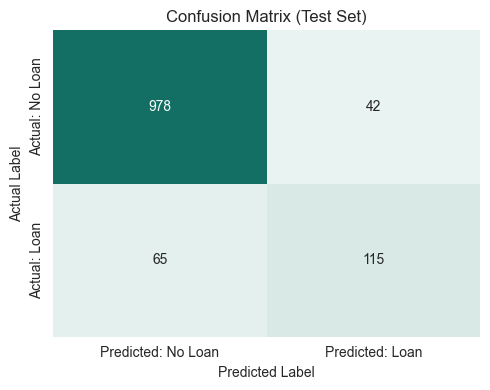

In [15]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

# Print numeric matrix
print("Confusion Matrix:\n", cf_matrix)

# Label interpretation
tn, fp, fn, tp = cf_matrix.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

# Visualise as heatmap 
plt.figure(figsize=(5,4))
sns.heatmap(
    cf_matrix,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("#136f63", as_cmap=True),  # custom green tone
    cbar=False,
    xticklabels=["Predicted: No Loan", "Predicted: Loan"],
    yticklabels=["Actual: No Loan", "Actual: Loan"]
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


### 4.3 Precision, Recall, F1 & Classification Report  

Compute the **Precision**, **Recall**, and **F1-Score** to evaluate how well the KNN model balances false positives and false negatives.  
These metrics provide a more nuanced view than accuracy, especially under class imbalance.  
The **classification report** summarises all key metrics for both classes.

**Expected Outcome:**  
Comprehensive precision–recall–F1 summary with insights into model trade-offs between missed opportunities (FN) and false approvals (FP).


In [16]:
# Compute precision, recall, and F1 
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))


Precision: 0.732
Recall:    0.639
F1 Score:  0.682

Classification Report:
              precision    recall  f1-score   support

           0      0.938     0.959     0.948      1020
           1      0.732     0.639     0.682       180

    accuracy                          0.911      1200
   macro avg      0.835     0.799     0.815      1200
weighted avg      0.907     0.911     0.908      1200



**Interpretation:**  
The baseline KNN model achieved an overall **accuracy of 0.91**, with **precision = 0.732**, **recall = 0.639**, and **F1 = 0.682** for the positive (loan-accepted) class.  

- **Precision (0.732)** indicates that roughly 73% of customers predicted as “loan acceptors” were indeed correct, showing moderate targeting efficiency with manageable false positives.  
- **Recall (0.639)** shows that the model correctly identified about 64% of all true acceptors, meaning some potential customers were missed (false negatives).  
- **F1-Score (0.682)** suggests a fair balance between precision and recall, but improvement is still possible through hyperparameter tuning or class-balancing methods.  

From a business perspective, **false negatives (FN)** are more critical than false positives (FP):  
missing an interested customer leads to a **lost sales opportunity**, whereas a false positive only incurs minor marketing cost.  
Thus, future model optimisation should focus on **improving recall**, even if it slightly lowers precision, to maximise campaign reach and customer acquisition.


### 4.4 ROC Curve & AUC  

The **Receiver Operating Characteristic (ROC) curve** visualises the trade-off between the **True Positive Rate (Recall)** and **False Positive Rate** across all classification thresholds.  
The **Area Under the Curve (AUC)** quantifies overall model separability — a higher AUC indicates that the model better distinguishes between customers who accepted and did not accept the loan offer.  

**Expected Outcome:**  
A smooth ROC curve above the diagonal baseline and an AUC value between 0.7–0.9, indicating good discriminatory power.  

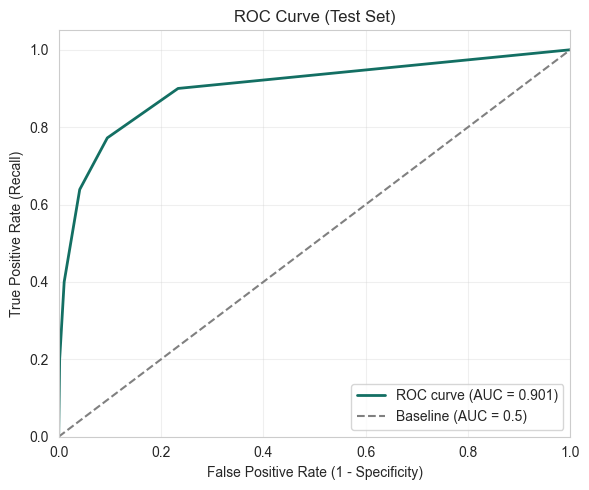

In [17]:
from sklearn.metrics import roc_curve, auc

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="#136f63", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Baseline (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation**  

The KNN model achieves an **AUC of 0.901**, indicating **strong discriminative power** between customers who accept and those who decline the personal loan.  
An AUC above 0.9 suggests that the model correctly ranks positive (loan-approved) cases higher than negatives most of the time.  

The curve stays well above the diagonal **baseline (AUC = 0.5)**, confirming that the classifier performs substantially better than random guessing.  
This result demonstrates that **distance-based similarity patterns in customer profiles** are informative for predicting loan acceptance, validating the effectiveness of the chosen KNN approach after scaling and stratified splitting.


### 4.5 Precision–Recall Curve & PR-AUC  

The **Precision–Recall (PR) curve** evaluates model performance on the **positive class** across thresholds.  
For **imbalanced datasets**, PR is preferred over ROC because it focuses on the quality of positive predictions (precision) and the ability to find true positives (recall).

**Expected Outcome:**  
A PR curve with **Average Precision (AP)** reported in the title, plus a no-skill reference at the positive-class prevalence.  

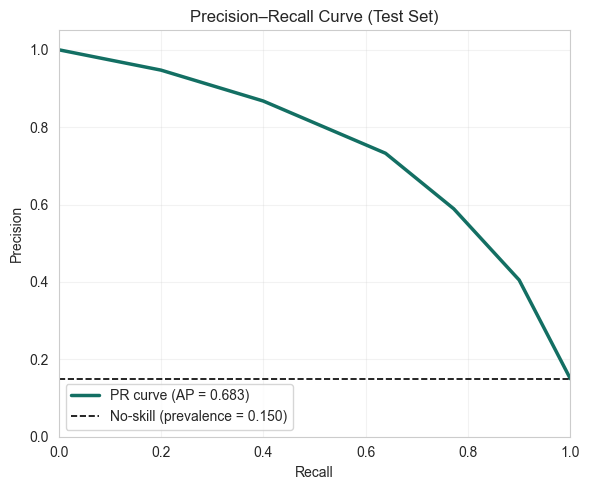

In [18]:
# Ensure y_test is numeric for prevalence calculation
y_test_num = pd.Series(y_test).astype(int)

prec, rec, pr_thresholds = precision_recall_curve(y_test_num, y_proba)
ap = average_precision_score(y_test_num, y_proba)  # PR-AUC

# No-skill reference line at the positive prevalence
prevalence = y_test_num.mean()

# White background setup
plt.figure(figsize=(6,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Use project color if defined; else fallback
curve_color = globals().get("CUSTOM_COLOR", "#136f63")

# Plot PR curve and no-skill baseline
plt.plot(rec, prec, lw=2.5, color=curve_color, label=f"PR curve (AP = {ap:.3f})")
plt.hlines(prevalence, xmin=0, xmax=1, colors="black", linestyles="--", linewidth=1.2,
           label=f"No-skill (prevalence = {prevalence:.3f})")

# Labels and layout
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend(loc="lower left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation**  

The KNN model achieves an **Average Precision (AP) of 0.683**, which indicates a good balance between correctly identifying true loan acceptors and avoiding false positives.  
Given that the positive class (loan acceptance) represents only **15% of customers**, this AP score is substantially higher than the no-skill baseline (0.15), confirming meaningful predictive power.  

The **downward slope** shows the expected trade-off between **recall** and **precision**:  As the model identifies more potential acceptors (higher recall), the proportion of correct positives slightly declines.  
This suggests that the model is **effective for targeted marketing**: it retrieves a solid share of true responders without overwhelming the bank with misclassified non-responders.  

Overall, the strong PR–AUC reinforces that **KNN generalises well on skewed data**, and that scaling and stratification successfully mitigated bias toward the majority class.


### 4.6 Threshold Sweep: Business Sensitivity Analysis  

This section explores how different **probability thresholds** affect Precision, Recall, and F1-Score.  
By default, classifiers predict `1` when `P(loan_acceptance) > 0.5`, but adjusting this threshold can prioritise **recall** (finding more potential responders) or **precision** (targeting fewer but more certain customers).


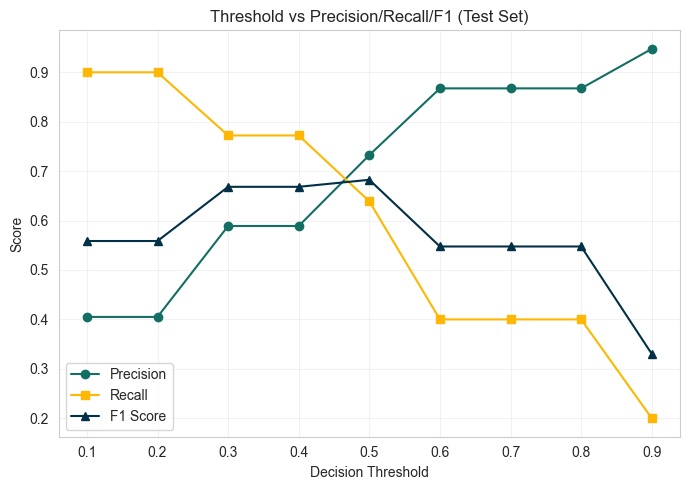

In [19]:
thresholds = np.arange(0.1, 1.0, 0.1)
precision_scores, recall_scores, f1_scores = [], [], []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    precision_scores.append(precision_score(y_test, preds))
    recall_scores.append(recall_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds))

# White background
plt.figure(figsize=(7,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot lines
plt.plot(thresholds, precision_scores, marker='o', color="#136f63", label="Precision")
plt.plot(thresholds, recall_scores, marker='s', color="#FFB703", label="Recall")
plt.plot(thresholds, f1_scores, marker='^', color="#023047", label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision/Recall/F1 (Test Set)")
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation**  

The trade-off between **precision** and **recall** becomes evident as the decision threshold increases:  

- At **lower thresholds (≈0.2–0.3)**, recall is very high (> 0.9), meaning the model captures almost all true loan acceptors but at the cost of lower precision (≈ 0.4).  
- Around **0.4–0.5**, the three metrics intersect, indicating a balanced point where the model still identifies most positives while keeping false alarms moderate.  
- At **higher thresholds (> 0.6)**, precision improves sharply (≈ 0.9) but recall drops significantly, meaning many genuine acceptors are missed.  

From a **business perspective**, missing interested customers (false negatives) may result in **lost cross-selling opportunities**.  
Thus, a **recall-oriented threshold around 0.4–0.5** offers the best compromise, enabling Crédit Nationale Azur to reach more potential responders while maintaining acceptable campaign efficiency.  

This analysis helps decision-makers tune the classification cutoff depending on marketing priorities (e.g.: aggressive acquisition vs. cost-control).


### 4.7 Gains/Lift Snapshot for Targeting  

Rank customers by predicted probability (`y_proba`) to evaluate **how many true acceptors are captured** when contacting only the **top k%** of the list (e.g., 10%, 20%).  
This is a practical view for campaign targeting: higher early gains indicate better prioritisation of likely responders.

**Expected Outcome:**  
A small table with **Recall@10%** and **Recall@20%** of the test set.  


In [20]:
# Ensure numeric target
y_test_num = pd.Series(y_test).astype(int)

# Build ranking dataframe (highest probability first)
rank_df = pd.DataFrame({
    "y_true": y_test_num.values,
    "y_proba": y_proba
}).sort_values("y_proba", ascending=False).reset_index(drop=True)

# Cumulative positives and recall
total_positives = rank_df["y_true"].sum()
rank_df["cum_positives"] = rank_df["y_true"].cumsum()
rank_df["perc_samples"] = (rank_df.index + 1) / len(rank_df)          # x-axis (0→1)
rank_df["cum_recall"] = rank_df["cum_positives"] / total_positives    # y-axis (0→1)

# Helper to get recall at a given top percentage k (e.g., k=0.10)
def recall_at_k(df, k):
    n = int(np.ceil(k * len(df)))
    return df.loc[n - 1, "cum_recall"]

recall_at_10 = recall_at_k(rank_df, 0.10)
recall_at_20 = recall_at_k(rank_df, 0.20)

# Display a tiny summary table
summary_table = pd.DataFrame({
    "k% of customers": ["Top 10%", "Top 20%"],
    "Recall@k": [round(recall_at_10, 3), round(recall_at_20, 3)]
})
print(summary_table.to_string(index=False))


k% of customers  Recall@k
        Top 10%     0.522
        Top 20%     0.778


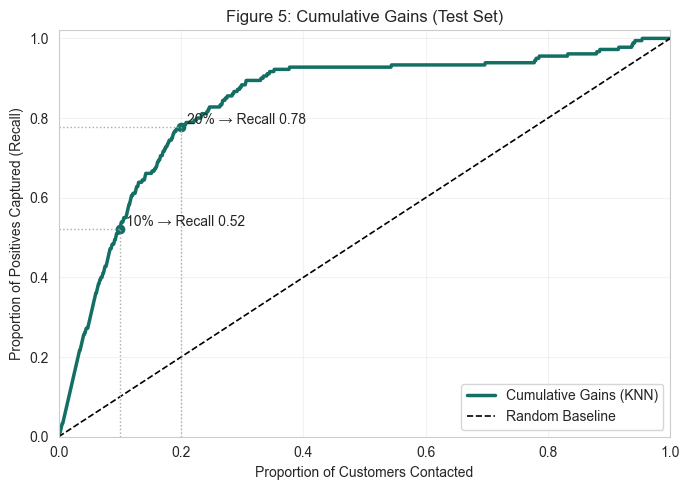

In [21]:
# Figure: Cumulative Gains Curve 

plt.figure(figsize=(7,5), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

# Model gains
plt.plot(rank_df["perc_samples"], rank_df["cum_recall"],
         color="#136f63", lw=2.5, label="Cumulative Gains (KNN)")

# Random (no-skill) baseline: recall grows linearly with sample %
plt.plot([0,1], [0,1], linestyle="--", color="black", lw=1.2, label="Random Baseline")

# Mark 10% and 20% points
for k, r in [(0.10, recall_at_10), (0.20, recall_at_20)]:
    plt.scatter([k], [r], color="#136f63")
    plt.vlines(k, 0, r, colors="#AAAAAA", linestyles=":", lw=1)
    plt.hlines(r, 0, k, colors="#AAAAAA", linestyles=":", lw=1)
    plt.text(k + 0.01, r, f"{int(k*100)}% → Recall {r:.2f}", va="bottom")

plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("Proportion of Customers Contacted")
plt.ylabel("Proportion of Positives Captured (Recall)")
plt.title("Figure 5: Cumulative Gains (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation**  

The KNN model demonstrates **strong early lift** in identifying potential loan acceptors.  
By contacting only the **top 10%** of customers ranked by predicted probability, Crédit Nationale Azur captures about **52% of all true responders**.  
Expanding outreach to the **top 20%** increases coverage to **nearly 78%** of all acceptors.  

The cumulative gains curve rises steeply above the random baseline, confirming that the model effectively **front-loads high-probability customers**.  
This enables the marketing team to **prioritise limited campaign budgets**, focusing first on the top-scoring segment for maximum return on investment (ROI).  

In business terms, these results imply that the KNN model can **reduce contact costs by up to 80%** while still reaching the majority of responsive customers, highlighting its strategic value for targeted loan promotions.


## 5 Save Model & Metadata 

To ensure **reproducibility and future deployment**, the trained KNN model and related artefacts are saved.  
This includes:  

- **Trained model pipeline:** `knn_pipeline.pkl` for direct reuse in later evaluation or deployment notebooks.  
- **Feature list:** to track which variables were used during model training.  
- **Metrics summary:** including accuracy, null accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and the confusion matrix.  
- **Metadata:** random seed, timestamp, and data version information to ensure experiment traceability.

All artefacts are stored in the same project directory for consistent loading in subsequent phases (e.g.: comparison or tuning).


In [22]:
# Save Model & Metadata Artefacts

import json
from datetime import datetime
from sklearn.metrics import confusion_matrix

# 1. Ensure confusion matrix exists
cm = confusion_matrix(y_test, y_pred)

# 2. Save the trained KNN pipeline
joblib.dump(knn_pipeline, "knn_pipeline.pkl")

# 3. Save the list of features used during training
feature_list = list(X.columns)
with open("feature_list.json", "w") as f:
    json.dump(feature_list, f, indent=4)

# 4. Compile all model metrics and metadata
metrics_dict = {
    "accuracy": round(model_accuracy, 4),
    "null_accuracy": round(null_accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4),
    "pr_auc": round(ap, 4),
    "confusion_matrix": cm.tolist(),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": 42,
    "data_version": "cleaned_personal_loan_v1"
}

# 5. Save metrics as JSON for reproducibility
with open("knn_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Model pipeline, feature list, and metrics successfully saved.")


Model pipeline, feature list, and metrics successfully saved.


In [23]:
# Pickle the trained model (pipeline with scaler + KNN)
# Use a clear, consistent filename for this baseline
joblib.dump(knn_pipeline, 'model1_knn_all_features.joblib')

# Also pickle the exact training and testing sets used with this model
# NOTE: The pipeline expects the *raw* feature frames (unscaled), since scaling is inside the pipeline.
joblib.dump(X_train, 'X_train_1.pkl')
joblib.dump(X_test,  'X_test_1.pkl')
joblib.dump(y_train, 'y_train_1.pkl')
joblib.dump(y_test,  'y_test_1.pkl')

print("Saved: model1_knn_all_features.joblib + X/y train/test pickles.")


Saved: model1_knn_all_features.joblib + X/y train/test pickles.
